Name: Lathika M
Roll No: 24BAD062
Scenario 1: SCENARIO 1 – MULTINOMIAL NAÏVE BAYES
/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv

Dataset Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Accuracy: 0.9730941704035875
Precision: 0.8742138364779874
Recall: 0.9328859060402684
F1 Score: 0.9025974025974026

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       966
           1       0.87      0.93      0.90       149

    accuracy                           0.97      1115
   macro avg       0.93      0.96      0.94      1115
weighted avg       0.97      0.97      0.97 

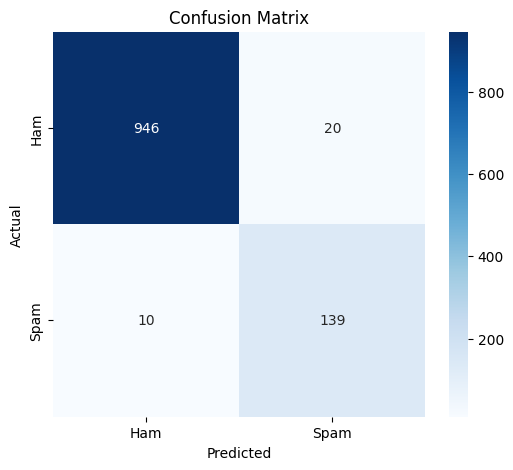


Number of Misclassified Messages: 30

Message: Did u got that persons story
Actual: spam
Predicted: ham

Message: Yeah you should. I think you can use your gt atm now to register. Not sure but if there's anyway i can help let me know. But when you do be sure you are ready.
Actual: spam
Predicted: ham

Message: U 447801259231 have a secret admirer who is looking 2 make contact with U-find out who they R*reveal who thinks UR so special-call on 09058094597
Actual: ham
Predicted: spam

Message: No objection. My bf not coming.
Actual: ham
Predicted: spam

Message: Message:some text missing* Sender:Name Missing* *Number Missing *Sent:Date missing *Missing U a lot thats y everything is missing sent via fullonsms.com
Actual: ham
Predicted: spam

Comparing Different Alpha Values

Alpha = 0.1 --> Accuracy = 0.9766816143497757
Alpha = 0.5 --> Accuracy = 0.9757847533632287
Alpha = 1.0 --> Accuracy = 0.9730941704035875
Alpha = 2.0 --> Accuracy = 0.9775784753363229

Top Words Influencing Spam:
 ['u

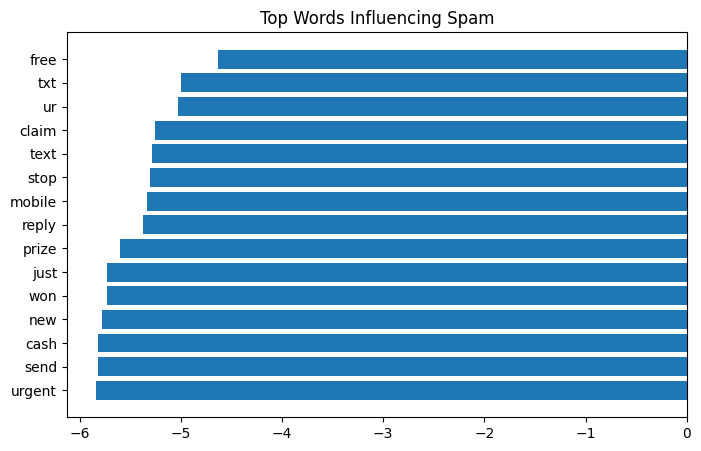

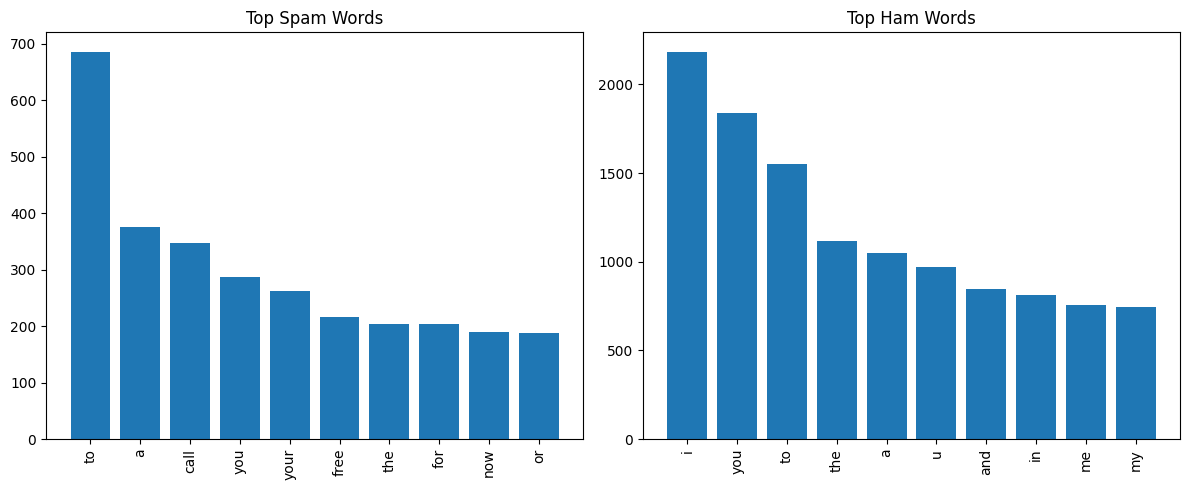

In [12]:
print("Name: Lathika M")
print("Roll No: 24BAD062")
print("Scenario 1: SCENARIO 1 – MULTINOMIAL NAÏVE BAYES")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data = pd.read_csv(
'/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',
encoding='latin-1'
)

data = data[['v1', 'v2']]
data.columns = ['label', 'message']

print("\nDataset Shape:", data.shape)
print(data.head())

def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

data['clean_message'] = data['message'].apply(clean_text)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['clean_message'])
encoder = LabelEncoder()
y = encoder.fit_transform(data['label'])  # ham=0, spam=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = MultinomialNB(alpha=1.0)  # Laplace smoothing
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

misclassified = np.where(y_test != y_pred)[0]

print("\nNumber of Misclassified Messages:", len(misclassified))

for i in misclassified[:5]:
    print("\nMessage:", data.iloc[i]['message'])
    print("Actual:", encoder.inverse_transform([y_test[i]])[0])
    print("Predicted:", encoder.inverse_transform([y_pred[i]])[0])

print("\nComparing Different Alpha Values\n")

for alpha in [0.1, 0.5, 1.0, 2.0]:
    model_alpha = MultinomialNB(alpha=alpha)
    model_alpha.fit(X_train, y_train)
    y_pred_alpha = model_alpha.predict(X_test)
    acc = accuracy_score(y_test, y_pred_alpha)
    print(f"Alpha = {alpha} --> Accuracy = {acc}")

feature_names = vectorizer.get_feature_names_out()
spam_class = 1

top_spam_indices = np.argsort(model.feature_log_prob_[spam_class])[-15:]
top_spam_words = [feature_names[i] for i in top_spam_indices]

print("\nTop Words Influencing Spam:\n", top_spam_words)

plt.figure(figsize=(8,5))
plt.barh(top_spam_words, model.feature_log_prob_[spam_class][top_spam_indices])
plt.title("Top Words Influencing Spam")
plt.show()

spam_words = ' '.join(data[data['label']=='spam']['clean_message'])
ham_words = ' '.join(data[data['label']=='ham']['clean_message'])

spam_counter = Counter(spam_words.split()).most_common(10)
ham_counter = Counter(ham_words.split()).most_common(10)

spam_words_list, spam_counts = zip(*spam_counter)
ham_words_list, ham_counts = zip(*ham_counter)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(spam_words_list, spam_counts)
plt.xticks(rotation=90)
plt.title("Top Spam Words")

plt.subplot(1,2,2)
plt.bar(ham_words_list, ham_counts)
plt.xticks(rotation=90)
plt.title("Top Ham Words")

plt.tight_layout()
plt.show()

Name: Lathika M
Roll No: 24BAD062
SCENARIO 2 - GAUSSIAN NAÏVE BAYES
Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Shape: (150, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  15

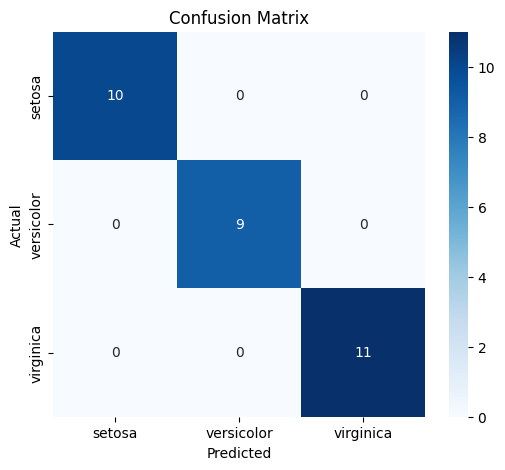


Class Probabilities (first 5 samples):
[[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]


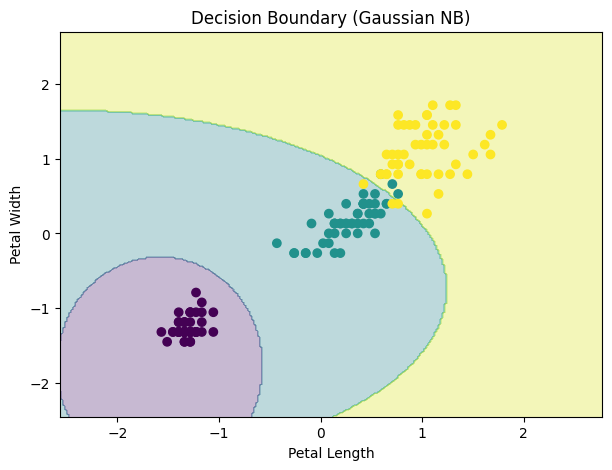

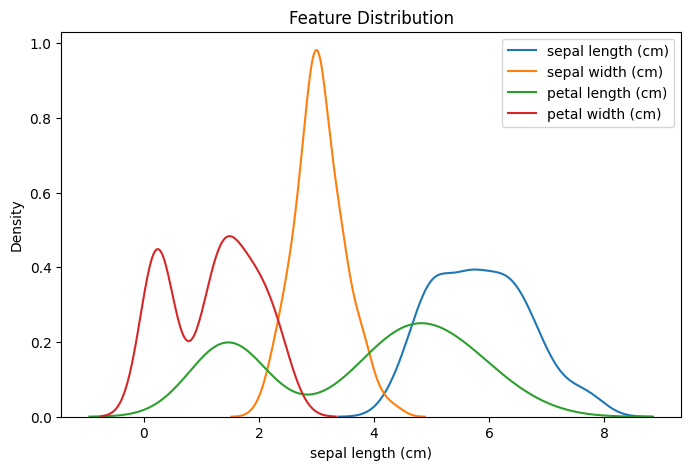


Logistic Regression Accuracy: 1.0


In [16]:
print("Name: Lathika M")
print("Roll No: 24BAD062")
print("SCENARIO 2 - GAUSSIAN NAÏVE BAYES")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

print("Dataset Preview:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nPrediction Comparison:")
print(comparison.head(10))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
probabilities = gnb.predict_proba(X_test)

print("\nClass Probabilities (first 5 samples):")
print(probabilities[:5])

X2 = df[['petal length (cm)', 'petal width (cm)']].values
y2 = df['species'].values

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42
)

model2 = GaussianNB()
model2.fit(X_train2, y_train2)

# mesh grid
x_min, x_max = X2_scaled[:,0].min()-1, X2_scaled[:,0].max()+1
y_min, y_max = X2_scaled[:,1].min()-1, X2_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X2_scaled[:,0], X2_scaled[:,1], c=y2, cmap='viridis')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary (Gaussian NB)")
plt.show()

plt.figure(figsize=(8,5))

for i, feature in enumerate(feature_names):
    sns.kdeplot(df[feature], label=feature)

plt.title("Feature Distribution")
plt.legend()
plt.show()

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))